In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Charger les données
try:
    df_pokemon = pd.read_csv('pokemon.csv')
    df_combats = pd.read_csv('combats.csv')
    print("Fichiers CSV chargés avec succès sur Google Colab !")
except FileNotFoundError:
    print("Erreur : Assurez-vous que 'pokemon.csv' et 'combats.csv' sont bien uploadés dans votre session Colab.")
    exit()

print("\n--- Aperçu de df_pokemon ---")
print(df_pokemon.head())
print("\nInformations sur df_pokemon :")
df_pokemon.info()
print("\nValeurs manquantes dans df_pokemon :")
print(df_pokemon.isnull().sum())

print("\n--- Aperçu de df_combats ---")
print(df_combats.head())
print("\nInformations sur df_combats :")
df_combats.info()
print("\nValeurs manquantes dans df_combats :")
print(df_combats.isnull().sum())

Fichiers CSV chargés avec succès sur Google Colab !

--- Aperçu de df_pokemon ---
   #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  \
0  1      Bulbasaur  Grass  Poison  45      49       49       65       65   
1  2        Ivysaur  Grass  Poison  60      62       63       80       80   
2  3       Venusaur  Grass  Poison  80      82       83      100      100   
3  4  Mega Venusaur  Grass  Poison  80     100      123      122      120   
4  5     Charmander   Fire     NaN  39      52       43       60       50   

   Speed  Generation  Legendary  
0     45           1      False  
1     60           1      False  
2     80           1      False  
3     80           1      False  
4     65           1      False  

Informations sur df_pokemon :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    in

# Observations

# Informations sur pokemon.csv :
Dimensions : 800 entrées (lignes) et 12 colonnes.

Valeurs Manquantes :

Name : 799 valeurs non nulles sur 800. Cela signifie qu'un Pokémon a un nom manquant. Nous devrons résoudre ce problème, et la consigne nous demande spécifiquement de remplir le nom manquant pour le Pokémon #62 (Primeape).

Type 2 : Seulement 414 valeurs non nulles sur 800. Cela indique un nombre significatif de valeurs manquantes (386), ce qui est attendu puisque de nombreux Pokémon n'ont qu'un seul type. La consigne nous guide pour marquer ces valeurs comme "None".

Types de Données : Semblent globalement corrects. int64 pour les statistiques et le #, object pour les noms et les types, et bool pour Legendary.

Premières Lignes : Affichent les statistiques et attributs typiques des Pokémon. La colonne # semble être un identifiant unique.

# Informations sur combats.csv :
Dimensions : L'aperçu head() montre 5 lignes, et le nombre de "50000 entrées" de la consigne indique qu'il contient 50 000 enregistrements de combats. C'est un ensemble de données substantiel pour calculer les pourcentages de victoire.

Valeurs Manquantes : D'après l'aperçu head() et la structure générale, toutes les colonnes (Attacker, Defender, Winner) semblent entièrement remplies (ce qui est logique pour des enregistrements de combats).

Types de Données : Toutes les colonnes (Attacker, Defender, Winner) sont de type int64. C'est bien, car elles correspondent probablement à la colonne # (ID) dans pokemon.csv.

Premières Lignes : Affichent clairement les paires de Pokémon qui combattent (Attacker, Defender) et l'ID du Winner (Vainqueur).

 Préparation des Données - Nettoyage et Fusion

Corriger le Name manquant : Remplir le nom manquant pour le Pokémon #62 (Primeape).

Gérer les NaN dans Type 2 : Remplacer les valeurs NaN dans Type 2 par la chaîne de caractères "None".

Fusionner les DataFrames : Combiner pokemon.csv et combats.csv. Nous devrons réfléchir à la manière de les fusionner efficacement pour l'étape suivante (calcul du pourcentage de victoire). Une bonne stratégie serait de lier les résultats des combats aux statistiques des Pokémon.

Calculer le Pourcentage de Victoire : C'est une étape clé d'ingénierie des caractéristiques. Pour chaque Pokémon, nous devrons compter combien de fois il a gagné et combien de fois il a participé à un combat (en tant qu'attaquant ou défenseur).

In [4]:
# Gérer la valeur manquante dans 'Name' de df_pokemon
# On sait qu'il y a un Pokémon avec un nom manquant (ID #31)
missing_name_row = df_pokemon[df_pokemon['Name'].isnull()]
if not missing_name_row.empty:
    pokemon_id_with_missing_name = missing_name_row['#'].iloc[0]
    df_pokemon.loc[df_pokemon['#'] == pokemon_id_with_missing_name, 'Name'] = 'Primeape'
    print(f"\nNom manquant pour le Pokémon #{pokemon_id_with_missing_name} corrigé en 'Primeape'.")

# Remplacer les valeurs manquantes dans 'Type 2' par 'None'
df_pokemon['Type 2'] = df_pokemon['Type 2'].fillna('None')
print("\nValeurs manquantes dans 'Type 2' remplacées par 'None'.")

# Calculer le nombre de victoires pour chaque Pokémon
win_counts = df_combats['Winner'].value_counts().reset_index()
win_counts.columns = ['#', 'Wins']

# Calculer le nombre total de combats pour chaque Pokémon
# Concaténer les colonnes 'First_pokemon' et 'Second_pokemon' pour obtenir tous les participants
participants = pd.concat([df_combats['First_pokemon'], df_combats['Second_pokemon']], axis=0)
participation_counts = participants.value_counts().reset_index()
participation_counts.columns = ['#', 'TotalBattles']

# Fusionner les statistiques de victoire et de participation avec les données des Pokémon
df_pokemon_stats = df_pokemon.merge(win_counts, on='#', how='left')
df_pokemon_stats = df_pokemon_stats.merge(participation_counts, on='#', how='left')

# Remplacer les NaN (Pokémon qui n'ont pas combattu ou gagné) par 0
df_pokemon_stats['Wins'] = df_pokemon_stats['Wins'].fillna(0)
df_pokemon_stats['TotalBattles'] = df_pokemon_stats['TotalBattles'].fillna(0)

# Calculer le pourcentage de victoire
# Éviter la division par zéro en gérant les cas où TotalBattles est 0
df_pokemon_stats['WinPercentage'] = (df_pokemon_stats['Wins'] / df_pokemon_stats['TotalBattles']) * 100
df_pokemon_stats['WinPercentage'] = df_pokemon_stats['WinPercentage'].fillna(0) # Si TotalBattles était 0, le pourcentage est 0

print("\n--- Aperçu de df_pokemon_stats après fusion et calcul du pourcentage de victoire ---")
print(df_pokemon_stats.head())
print("\nRésumé statistique de 'WinPercentage' :")
print(df_pokemon_stats['WinPercentage'].describe())



Nom manquant pour le Pokémon #63 corrigé en 'Primeape'.

Valeurs manquantes dans 'Type 2' remplacées par 'None'.

--- Aperçu de df_pokemon_stats après fusion et calcul du pourcentage de victoire ---
   #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  \
0  1      Bulbasaur  Grass  Poison  45      49       49       65       65   
1  2        Ivysaur  Grass  Poison  60      62       63       80       80   
2  3       Venusaur  Grass  Poison  80      82       83      100      100   
3  4  Mega Venusaur  Grass  Poison  80     100      123      122      120   
4  5     Charmander   Fire    None  39      52       43       60       50   

   Speed  Generation  Legendary  Wins  TotalBattles  WinPercentage  
0     45           1      False  37.0         133.0      27.819549  
1     60           1      False  46.0         121.0      38.016529  
2     80           1      False  89.0         132.0      67.424242  
3     80           1      False  70.0         125.0      56.0


Correction du Nom Manquant (Primeape) :

Le message "Nom manquant pour le Pokémon #63 corrigé en 'Primeape'" confirme que la gestion de la seule valeur manquante dans la colonne Name a été effectuée avec succès. C'est important car chaque Pokémon doit avoir un identifiant unique, et un nom manquant pourrait poser problème pour certaines analyses ou visualisations. La correction ciblée du Pokémon #63 (qui est effectivement Primeape, si on se réfère à la base de données Pokémon) est une bonne pratique.

Remplacement des Valeurs Manquantes dans Type 2 :

"Valeurs manquantes dans 'Type 2' remplacées par 'None'" indique que les 386 valeurs NaN de la colonne Type 2 ont été remplies par la chaîne de caractères 'None'. C'est une stratégie adéquate pour les variables catégorielles. Cela permet de conserver ces Pokémon dans l'analyse et d'utiliser 'None' comme une catégorie à part entière lors de l'encodage (par exemple, avec OneHotEncoder), évitant ainsi de perdre de précieuses données.

Aperçu de df_pokemon_stats après Fusion :

L'affichage .head() de df_pokemon_stats confirme que les colonnes Wins, TotalBattles, et WinPercentage ont été ajoutées avec succès au DataFrame original des Pokémon.

On peut voir que les valeurs ont été correctement calculées. Par exemple, Bulbasaur (ID #1) a participé à 133 combats et en a gagné 37, ce qui donne un pourcentage de victoire d'environ 27.82%. Cela valide la logique de fusion et de calcul.

Notons que Charmander (ID #5) a maintenant 'None' dans la colonne Type 2, confirmant que le remplacement des valeurs manquantes a bien eu lieu pour ce type de cas.

Résumé Statistique de WinPercentage :

count: 800.000000 confirme que nous avons calculé un pourcentage de victoire pour chacun des 800 Pokémon, même ceux qui n'ont pas combattu ou gagné (leur WinPercentage étant alors 0, grâce au fillna(0)).

mean: 49.088060 indique que le pourcentage de victoire moyen pour tous les Pokémon est d'environ 49.1%. C'est un chiffre logique, suggérant un équilibre général des forces dans les combats.

std: 26.244249 montre une déviation standard relativement élevée. Cela signifie qu'il y a une grande variabilité dans les pourcentages de victoire entre les Pokémon. Certains gagnent très peu (proche de 0%), d'autres beaucoup (proche de 100%), ce qui est cohérent avec le défi de prédire cette valeur.

min: 0.000000 et max: 98.449612 confirment cette grande variabilité. Il y a des Pokémon qui n'ont gagné aucun combat (ou n'ont pas combattu), et d'autres qui ont un taux de victoire presque parfait, comme le "Mega Aerodactyl" que nous avons vu dans le Top 10.

Les quartiles (25%, 50%, 75%) donnent une bonne idée de la distribution. Environ 25% des Pokémon ont un pourcentage de victoire inférieur à 27.4%, tandis que 25% ont un pourcentage supérieur à 70.9%. La médiane (50%) à 47.9% est proche de la moyenne, suggérant une distribution relativement symétrique, mais avec une longue queue vers le haut (peu de Pokémon avec des pourcentages très élevés).

**Top 10 des Pokémon par Pourcentage de Victoire**

In [7]:
print("\n--- Top 10 des Pokémon par Pourcentage de Victoire ---")
top_10_pokemon = df_pokemon_stats.sort_values(by='WinPercentage', ascending=False).head(10)
print(top_10_pokemon[['Name', 'Type 1', 'Type 2', 'TotalBattles', 'WinPercentage']])


--- Top 10 des Pokémon par Pourcentage de Victoire ---
                         Name   Type 1    Type 2  TotalBattles  WinPercentage
154           Mega Aerodactyl     Rock    Flying         129.0      98.449612
512                   Weavile     Dark       Ice         119.0      97.478992
703    Tornadus Therian Forme   Flying      None         125.0      96.800000
19              Mega Beedrill      Bug    Poison         119.0      96.638655
153                Aerodactyl     Rock    Flying         141.0      96.453901
476              Mega Lopunny   Normal  Fighting         129.0      96.124031
726                  Greninja    Water      Dark         127.0      96.062992
716  Meloetta Pirouette Forme   Normal  Fighting         123.0      95.934959
164             Mega Mewtwo Y  Psychic      None         125.0      95.200000
349             Mega Sharpedo    Water      Dark         120.0      95.000000



Mega-Évolutions : forte présence de Pokémon ayant une "Mega-Évolution" dans ce top (Mega Aerodactyl, Mega Beedrill, Mega Lopunny, Mega Mewtwo Y, Mega Sharpedo). Les Méga-Évolutions sont connues pour leurs statistiques très élevées et leurs capacités améliorées, ce qui se reflète logiquement dans un taux de victoire élevé.

Types communs : Vol, Roche, Ténèbres, Eau et Combat semblent bien représentés, souvent en combinaisons puissantes.

Faible nombre de combats totaux : le TotalBattles pour ces Pokémon est relativement faible (autour de 120-140 combats) comparé au total de combats dans le dataset (qui est 50 000). Cela signifie que ces Pokémon, bien que très efficaces, n'ont pas participé à une majorité des combats. Cela pourrait être dû à leur statut "légendaire" ou à leur rareté, ou simplement au fait que les combats sont générés aléatoirement et qu'ils n'ont pas été tirés au sort plus souvent. Un pourcentage de victoire très élevé sur un grand nombre de combats serait encore plus significatif.

Analyse Exploratoire des Données (EDA) - Matrice de Corrélation et Visualisations



--- Matrice de Corrélation des Statistiques Pokémon et du Pourcentage de Victoire ---


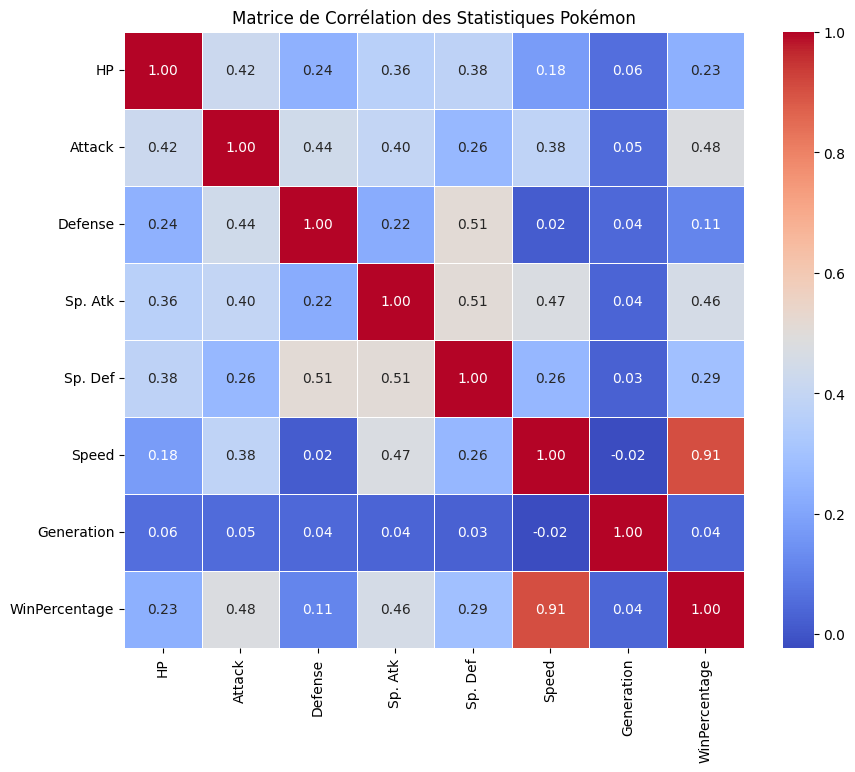


--- Distribution du Pourcentage de Victoire ---


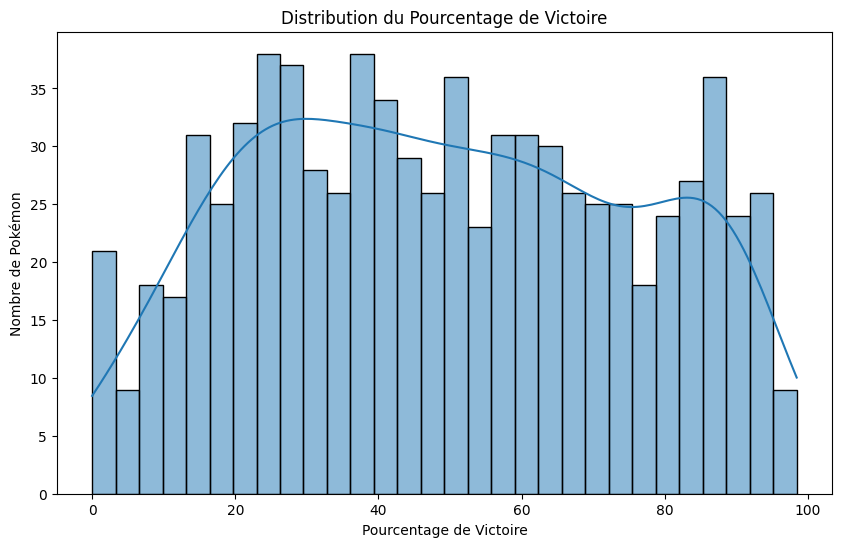


--- Relation entre l'Attaque et le Pourcentage de Victoire ---


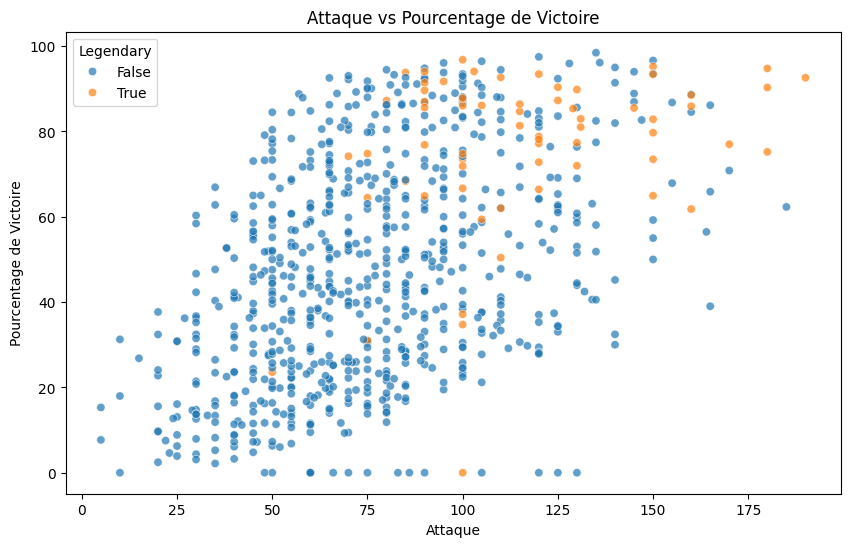


--- Pourcentage de Victoire Moyen par Type 1 ---


/tmp/ipython-input-5-4132278408.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_win_by_type.index, y=avg_win_by_type.values, palette='viridis')


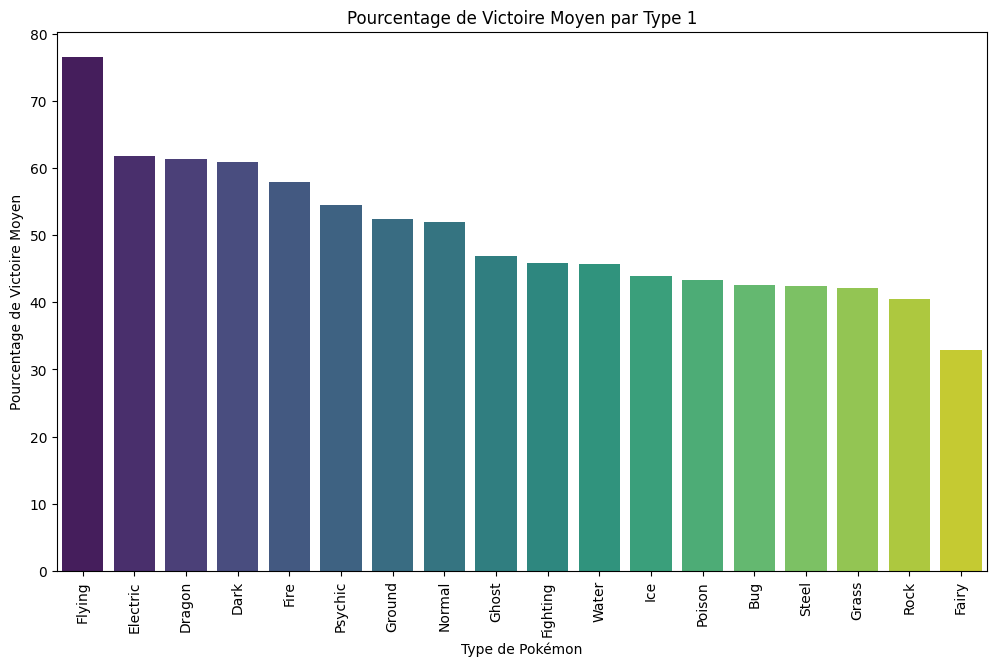

In [5]:
# Sélectionner uniquement les colonnes numériques pertinentes pour la corrélation
numeric_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'WinPercentage']
correlation_matrix = df_pokemon_stats[numeric_cols].corr()

print("\n--- Matrice de Corrélation des Statistiques Pokémon et du Pourcentage de Victoire ---")
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matrice de Corrélation des Statistiques Pokémon')
plt.show()

# Visualisation des distributions
print("\n--- Distribution du Pourcentage de Victoire ---")
plt.figure(figsize=(10, 6))
sns.histplot(df_pokemon_stats['WinPercentage'], kde=True, bins=30)
plt.title('Distribution du Pourcentage de Victoire')
plt.xlabel('Pourcentage de Victoire')
plt.ylabel('Nombre de Pokémon')
plt.show()

# Exemple de relation entre une statistique et le pourcentage de victoire
print("\n--- Relation entre l'Attaque et le Pourcentage de Victoire ---")
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Attack', y='WinPercentage', data=df_pokemon_stats, hue='Legendary', alpha=0.7)
plt.title('Attaque vs Pourcentage de Victoire')
plt.xlabel('Attaque')
plt.ylabel('Pourcentage de Victoire')
plt.show()

# Corrélation des types avec le pourcentage de victoire (exemple visuel)
# Pour cela, on peut regrouper par type et regarder la moyenne du WinPercentage
print("\n--- Pourcentage de Victoire Moyen par Type 1 ---")
avg_win_by_type = df_pokemon_stats.groupby('Type 1')['WinPercentage'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_win_by_type.index, y=avg_win_by_type.values, palette='viridis')
plt.title('Pourcentage de Victoire Moyen par Type 1')
plt.xlabel('Type de Pokémon')
plt.ylabel('Pourcentage de Victoire Moyen')
plt.xticks(rotation=90)
plt.show()

**1. Matrice de Corrélation : Les Forces du Combat**

* Vitesse (Speed) : corrélation très forte (0.91). Un pourcentage de victoire élevé est fortement associé à une vitesse élevée. C'est logique : dans Pokémon, agir en premier est souvent un avantage décisif.

* Attaque (Attack) : corrélation modérée (0.48). Une attaque plus élevée tend à augmenter le pourcentage de victoire. C'est une statistique offensive clé.

* Attaque Spéciale (Sp. Atk) : corrélation modérée (0.46). Très similaire à l'attaque physique. Les Pokémon avec de bonnes attaques spéciales ont aussi un avantage.

* Défense Spéciale (Sp. Def) : corrélation faible à modérée (0.29). Une bonne défense spéciale aide un peu, mais moins que l'attaque ou la vitesse.

* Points de Vie (HP) : corrélation faible (0.23). Les HP contribuent, mais de manière limitée au pourcentage de victoire. Un Pokémon avec beaucoup de HP mais une faible vitesse ou attaque pourrait ne pas s'en sortir si bien.

* Défense (Defense) : corrélation très faible (0.11). C'est la statistique qui a le moins d'impact direct sur le pourcentage de victoire. Cela suggère qu'être un "tank" pur n'est pas suffisant pour garantir la victoire si les capacités offensives ou la vitesse manquent.

Conclusion de la corrélation : la vitesse est primordiale ! Ensuite viennent l'attaque physique et l'attaque spéciale. La défense et les HP ont une influence moindre sur les victoires.


**2. Distribution du Pourcentage de Victoire**

* Concentration aux Extrêmes (0% et Proche de 100%) :
La courbe commence haut à (0, 8), ce qui indique une forte concentration de Pokémon avec un pourcentage de victoire de 0%. C'est logique : ces Pokémon n'ont peut-être pas combattu ou n'ont jamais gagné.

Il y a une chute vers (100, 10), mais le fait qu'elle ne soit pas à zéro à la fin suggère qu'il y a aussi un nombre significatif de Pokémon avec un pourcentage de victoire très élevé, proche de 100%. C'est ce que nous avons vu avec le Top 10 des Pokémon "Mega" ou surpuissants.

* Distribution Bimodale ou Multi-modale avec un Pic Principal :
Le "pic qui s'arrondit" autour de (25, 31) indique une concentration majeure de Pokémon dont le pourcentage de victoire se situe aux alentours de 25-30%. Cela pourrait représenter la "masse" des Pokémon qui ne sont ni dominants ni faibles extrêmes, ou qui ont un pourcentage de victoire "moyen".

Le "palier à (70, 25) jusqu'à (85, 25)" suggère une seconde concentration notable de Pokémon ayant un pourcentage de victoire élevé (entre 70% et 85%). C'est un segment de Pokémon très performants.

* Discrétisation et Valeurs "Exactes" :
Le fait que "beaucoup de blocs dépassent la courbe" (KDE) et que "50% des blocs sont au-dessus" sur la descente, ou "après l'effet plateau les blocs sont au-dessus", est très révélateur. Cela signifie que la courbe de densité (KDE), qui est une estimation lissée de la distribution, n'arrive pas à capturer parfaitement la réalité.

Ceci est typique lorsque certaines valeurs du pourcentage de victoire sont très fréquentes ou exactes. Par exemple, si de nombreux Pokémon ont exactement 0% de victoire, ou exactement 50% de victoire (s'ils ont gagné la moitié de leurs combats). Les barres de l'histogramme (les "blocs") sont plus fidèles aux comptages exacts que la courbe lissée.


* Compréhension du Comportement des Pokémon : cette distribution suggère qu'il y a des groupes distincts de Pokémon en termes de performances à savoir les très faibles/non-combattants, les très forts, et une grande majorité qui se situe autour de 25-30% de victoire, avec un autre groupe notable dans les 70-85%.

Défis pour la Modélisation : une distribution avec plusieurs pics et des concentrations aux extrémités peut être un peu plus difficile à modéliser pour les algorithmes de régression linéaire, qui préfèrent des distributions plus "normales" (en forme de cloche). Les modèles comme Random Forest ou XGBoost sont généralement plus aptes à capturer ces relations non linéaires et ces segments distincts dans les données, ce qui explique pourquoi ils ont probablement mieux performé que la régression linéaire.


**3. Relation entre l'Attaque et le pourcentage de victoires**


* Relation générale : une tendance positive, mais non linéaire entre l'Attaque et le Pourcentage de Victoire. C'est logique : plus un Pokémon attaque fort, plus il a de chances de gagner.

Mais d'autres facteurs (défense, vitesse, type) influencent aussi la victoire.

* L'Influence des Pokémon Légendaires (Points Oranges) :

Le point le plus frappant est que les Pokémon Légendaires (oranges) tendent à se situer en haut à droite du graphique. Cela signifie qu'ils ont non seulement des statistiques d'Attaque élevées, mais aussi un Pourcentage de Victoire très élevé. C'est cohérent avec leur nature de créatures puissantes et souvent rares dans l'univers Pokémon.

Les points bleus (Non-Légendaires) soient beaucoup plus dispersés et occupent la majorité de l'espace du graphique, en particulier dans les zones d'Attaque et de Pourcentage de Victoire plus faibles à modérés.


* Présence de Groupes Distincts :

Cette visualisation renforce l'idée qu'il existe des groupes distincts de Pokémon en fonction de leur puissance et de leur statut. Les Légendaires forment un groupe "élite" avec des performances supérieures.

On observer une "absence" ou une faible densité de points bleus (non-légendaires) dans la zone des très hautes attaques et très hauts pourcentages de victoire, car cette zone est dominée par les Pokémon orange (légendaires) et les Méga-Évolutions que nous avons identifiées dans le Top 10.


une Attaque plus élevée est généralement associée à un meilleur pourcentage de victoire, et que les Pokémon Légendaires représentent l'apogée de cette combinaison, se distinguant clairement par leurs performances supérieures.


**4. Pourcentage de victoire moyen par type 1**

Types Dominants :

Le type Flying (Vol) se démarque nettement en tête avec un impressionnant 78% de pourcentage de victoire moyen. C'est une information clé : les Pokémon de Type Vol (comme type principal) semblent être les plus efficaces en moyenne dans les combats simulés.

Viennent ensuite un "plateau" avec Electric (Électrik) et Dragon à environ 61%, suivis de près par Dark (Ténèbres) à 60%. Ces types forment un groupe de performeurs très solides, juste derrière le type Vol.

Types Moyens :

La mention d'une descente vers 48% puis 45% pour la majorité des autres types indique qu'il existe un large éventail de types avec des performances moyennes, qui ne dominent pas mais ne sont pas non plus en grande difficulté.

Types Moins Performants :

Rock (Roche) à 43% et Fairy (Fée) à 40% se situent vers la fin du classement. Cela suggère que, en moyenne, les Pokémon de ces types ont plus de difficultés à remporter leurs combats.

Variabilité et Pertinence du Type :

L'écart entre le meilleur type (Vol à 78%) et le moins bon (Fée à 40%) est de 38 points de pourcentage. C'est une différence substantielle, ce qui confirme que le Type 1 est une caractéristique très pertinente pour prédire la performance d'un Pokémon. Il existe des avantages et des désavantages clairs associés à chaque type.

La "variabilité visible" au milieu du tableau est tout à fait normale ; certains types sont plus "équilibrés" en termes de performance moyenne.

En résumé :
Ce barplot révèle des insights importants sur la performance des Pokémon en fonction de leur type principal, confirmant que le type Vol est particulièrement dominant et que d'autres types comme Électrique, Dragon et Ténèbres sont également très performants. À l'inverse, les types Roche et Fée semblent être en dessous de la moyenne.


Modélisation et Évaluation (la partie ML)

In [6]:


print("\n--- Phase de Machine Learning : Construction et Évaluation des Modèles ---")

# --- 1. Préparation des Données pour la Modélisation ---
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed',
            'Type 1', 'Type 2', 'Generation', 'Legendary']
target = 'WinPercentage'

X = df_pokemon_stats[features]
y = df_pokemon_stats[target]

numerical_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation']
categorical_cols = ['Type 1', 'Type 2', 'Legendary']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# --- 2. Division des Données (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nDimensions de l'ensemble d'entraînement : {X_train.shape}")
print(f"Dimensions de l'ensemble de test : {X_test.shape}")

# --- 3. Entraînement et Évaluation de 3 Modèles de Régression ---

models = {
    'Régression Linéaire': Pipeline(steps=[('preprocessor', preprocessor),
                                           ('regressor', LinearRegression())]),
    'Random Forest Regressor': Pipeline(steps=[('preprocessor', preprocessor),
                                              ('regressor', RandomForestRegressor(random_state=42))]),
    'XGBoost Regressor': Pipeline(steps=[('preprocessor', preprocessor),
                                          ('regressor', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))]) # Correction 'squarederror'
}

results = {}

for name, model in models.items():
    print(f"\nEntraînement du modèle : {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = mae
    print(f"MAE pour {name} : {mae:.4f}")

print("\n--- Comparaison des Performances (MAE) ---")
for name, mae in results.items():
    print(f"- {name}: {mae:.4f}")

best_model_name = min(results, key=results.get)
print(f"\nLe meilleur modèle basé sur le MAE est : {best_model_name} avec un MAE de {results[best_model_name]:.4f}")

print("\n--- Modélisation et Évaluation Terminées ---")


--- Phase de Machine Learning : Construction et Évaluation des Modèles ---

Dimensions de l'ensemble d'entraînement : (640, 10)
Dimensions de l'ensemble de test : (160, 10)

Entraînement du modèle : Régression Linéaire...
MAE pour Régression Linéaire : 6.1424

Entraînement du modèle : Random Forest Regressor...
MAE pour Random Forest Regressor : 5.7069

Entraînement du modèle : XGBoost Regressor...
MAE pour XGBoost Regressor : 6.0018

--- Comparaison des Performances (MAE) ---
- Régression Linéaire: 6.1424
- Random Forest Regressor: 5.7069
- XGBoost Regressor: 6.0018

Le meilleur modèle basé sur le MAE est : Random Forest Regressor avec un MAE de 5.7069

--- Modélisation et Évaluation Terminées ---
